In [2]:
import pandas as pd 

In [3]:
file_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\files\1216"
figure_path = r"E:\project8  Robotics and AI enable automation in modern proteomics\figures\1216"


In [4]:
# df = pd.read_csv(f'{file_path}\log_imputed_normalized_OrderedByTime_drugnames.csv', index_col = 0)
df = pd.read_csv(f'{file_path}\log_imputed_normalized_OrderedByTime_drugnames.csv', index_col = 0)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\project8  Robotics and AI enable automation in modern proteomics\\files\\1216\\log_imputed_normalized_OrderedByTime_drugnames.csv'

In [1]:
df

NameError: name 'df' is not defined

In [8]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
# ---------------------------------------------------
# 1. Input: QC-normalized log2 intensity matrix
#    Rows = proteins, Columns = samples
# ---------------------------------------------------
df2 = df.copy()

# ---------------------------------------------------
# 2. Identify DMSO samples and drug samples
# ---------------------------------------------------
columns = df2.columns

# DMSO columns contain "DMSO"
dms_cols = [c for c in columns if "DMSO" in c]

# All non-DMSO and non-QC columns (exclude QC)
drug_cols = [c for c in columns if ("DMSO" not in c) and ("_QC" not in c)]

# Extract drug names (remove trailing replicate index after the last "_")
def get_drug_name(col):
    # DFO and QC should not be treated as drugs
    if "DMSO" in col or "DFO" in col or "_QC" in col:
        return None
    # if "DFO" in col:
    #     return "Deferoxamine"
    # Example: "Caroverine (hydrochloride)_1" → "Caroverine (hydrochloride)"
    return col.rsplit("_", 1)[0]

drug_names = sorted(set(filter(None, (get_drug_name(c) for c in columns))))

print(f"Number of drugs detected: {len(drug_names)}")
print(drug_names)


Number of drugs detected: 170
['6-Mercaptopurine', 'ATP (dimagnesium)', 'Abemaciclib (methanesulfonate)', 'Acetophenazine (dimaleate)', 'Adiphenine (hydrochloride)', 'Alcaftadine', 'Alizapride (hydrochloride)', 'Almotriptan (malate)', 'Ambroxol', 'Amcinonide', 'Amiodarone (hydrochloride)', 'Amisulpride', 'Amodiaquine (dihydrochloride)', 'Anamorelin', 'Andrographolide', 'Aniracetam', 'Antazoline (hydrochloride)', 'Antipyrine', 'Asciminib', 'Atazanavir (sulfate)', 'Atorvastatin (hemicalcium salt)', 'Azatadine (dimaleate)', 'Azelastine (hydrochloride)', 'Baicalein', 'Balsalazide', 'Belzutifan', 'Benzamil (hydrochloride)', 'Benztropine (mesylate)', 'Bepotastine', 'Betahistine', 'Betamethasone dipropionate', 'Betamethasone disodium phosphate', 'Betamethasone valerate', 'Betazole', 'Bicyclol', 'Binimetinib', 'Bromhexine (hydrochloride)', 'Budesonide', 'Butylphthalide', 'Cabazitaxel', 'Camphor', 'Carbenoxolone (disodium)', 'Caroverine (hydrochloride)', 'Cetirizine (dihydrochloride)', 'Chlorop

In [147]:
# print(df2.isna().sum().tolist())

In [148]:
# ---------------------------------------------------
# 3. Perform Welch t-test for each drug vs DMSO
# ---------------------------------------------------
results = []

for drug in drug_names:
    # Collect replicates for this drug
    treat_cols = [c for c in drug_cols if c.startswith(drug)]

    # Skip drugs that have fewer than 2 replicates
    if len(treat_cols) < 2:
        # Optionally record skipped drugs
        # print(f"Skipping {drug}: only {len(treat_cols)} replicate(s)")
        continue

    # Perform t-test per protein
    for protein in df2.index:

        # Extract values and drop NaN
        x = df2.loc[protein, treat_cols].dropna().values  # drug replicates
        y = df2.loc[protein, dms_cols].dropna().values    # DMSO replicates

        # Skip if either group has fewer than 2 valid values
        if len(x) < 2 or len(y) < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            # Welch t-test (handles unequal variances)
            t_stat, p_val = ttest_ind(
                x, y,
                equal_var=False
            )

        # Store results
        results.append({
            "protein": protein,
            "drug": drug,
            "t_stat": t_stat,
            "p_value": p_val,
            "mean_drug": np.nanmean(x),
            "mean_DMSO": np.nanmean(y),
            "log2FC": np.nanmean(x) - np.nanmean(y)
        })

# Convert to DataFrame
df_ttest = pd.DataFrame(results)


In [149]:
# ---------------------------------------------------
# 1. Identify DFO columns (e.g. "Blue1_H1_DFO", etc.)
# ---------------------------------------------------
dfo_cols = [c for c in df2.columns if "DFO" in c]
print("Number of DFO samples:", len(dfo_cols))
print(dfo_cols[:10])

# If fewer than 2 DFO replicates exist, we can still compute,
# but t-test will be unstable. You can choose to skip in that case.
if len(dfo_cols) == 0:
    raise ValueError("No DFO columns found in df2.columns")

# ---------------------------------------------------
# 2. Perform Welch t-test for DFO vs DMSO only
# ---------------------------------------------------
results_dfo = []

for protein in df2.index:
    # Extract values for DFO and DMSO, drop NaNs
    x = df2.loc[protein, dfo_cols].dropna().values   # DFO values
    y = df2.loc[protein, dms_cols].dropna().values   # DMSO values

    # If either group has fewer than 2 valid values, set NaN
    if len(x) < 2 or len(y) < 2:
        t_stat, p_val = np.nan, np.nan
    else:
        t_stat, p_val = ttest_ind(
            x, y,
            equal_var=False
        )

    results_dfo.append({
        "protein": protein,
        "drug": "DFO",                        # or "Deferoxamine" if you prefer
        "t_stat": t_stat,
        "p_value": p_val,
        "mean_drug": np.nanmean(x),
        "mean_DMSO": np.nanmean(y),
        "log2FC": np.nanmean(x) - np.nanmean(y)   # DFO - DMSO
    })

df_dfo = pd.DataFrame(results_dfo)
print(df_dfo)

Number of DFO samples: 24
['Blue1_H1_DFO', 'Blue1_G1_DFO', 'Blue2_H1_DFO', 'Blue2_G1_DFO', 'Blue3_H1_DFO', 'Blue3_G1_DFO', 'Blue4_G1_DFO', 'Blue4_H1_DFO', 'Blue5_H1_DFO', 'Blue5_G1_DFO']
       protein drug     t_stat       p_value  mean_drug  mean_DMSO    log2FC
0       SMIM26  DFO -17.799316  2.766838e-17  18.013325  19.665528 -1.652202
1      MSANTD7  DFO  -1.707278  9.482326e-02  13.812543  14.018722 -0.206179
2         CAST  DFO  13.266621  3.649957e-16  24.767044  24.172447  0.594597
3        GNG5B  DFO   5.951637  4.340080e-07  18.117524  16.918388  1.199136
4         NKRF  DFO   3.497018  1.116491e-03  22.337681  22.179205  0.158476
...        ...  ...        ...           ...        ...        ...       ...
7877   FAM169A  DFO  11.023201  4.668484e-14  24.578848  24.079225  0.499623
7878      ZHX2  DFO  13.283740  3.143377e-16  21.415553  20.744229  0.671323
7879     MORC2  DFO  -0.509831  6.126959e-01  22.102131  22.128845 -0.026714
7880  IVNS1ABP  DFO -26.985476  1.659475e-2

In [150]:
# ---------------------------------------------------
# 3. Append DFO results into existing df_ttest
# ---------------------------------------------------
df_ttest_alldrugs = pd.concat([df_ttest, df_dfo], ignore_index=True)

print(df_ttest_alldrugs.tail())
print(df_ttest_alldrugs.shape)

          protein drug     t_stat       p_value  mean_drug  mean_DMSO  \
1339935   FAM169A  DFO  11.023201  4.668484e-14  24.578848  24.079225   
1339936      ZHX2  DFO  13.283740  3.143377e-16  21.415553  20.744229   
1339937     MORC2  DFO  -0.509831  6.126959e-01  22.102131  22.128845   
1339938  IVNS1ABP  DFO -26.985476  1.659475e-28  21.916716  23.581585   
1339939   SEC23IP  DFO  -3.547397  1.416185e-03  24.590362  24.819839   

           log2FC  
1339935  0.499623  
1339936  0.671323  
1339937 -0.026714  
1339938 -1.664869  
1339939 -0.229476  
(1339940, 7)


In [151]:
# ---------------------------------------------------
# 4. Adjust p-values using Benjamini–Hochberg FDR
# ---------------------------------------------------
df_ttest_alldrugs["p_value_adj"] = multipletests(
    df_ttest_alldrugs["p_value"],
    method="fdr_bh"
)[1]


# ---------------------------------------------------
# 5. Final tidy output for downstream analysis
# ---------------------------------------------------

print(df_ttest_alldrugs.head())
print(df_ttest_alldrugs.shape)

   protein              drug    t_stat   p_value  mean_drug  mean_DMSO  \
0   SMIM26  6-Mercaptopurine -2.241855  0.062626  19.459334  19.665528   
1  MSANTD7  6-Mercaptopurine -0.023353  0.982130  14.012529  14.018722   
2     CAST  6-Mercaptopurine  5.867678  0.000004  24.343017  24.172447   
3    GNG5B  6-Mercaptopurine -1.102815  0.311112  16.492365  16.918388   
4     NKRF  6-Mercaptopurine -1.101862  0.285503  22.137554  22.179205   

     log2FC  p_value_adj  
0 -0.206194     0.161444  
1 -0.006192     0.990476  
2  0.170570     0.000106  
3 -0.426023     0.488730  
4 -0.041650     0.461883  
(1339940, 8)


In [152]:
print(df_ttest_alldrugs["p_value"].head(20))
print(df_ttest_alldrugs["p_value"].isna().sum(), "/", len(df_ttest))
print(df_ttest_alldrugs["p_value"].dtype)

0     6.262588e-02
1     9.821299e-01
2     3.658536e-06
3     3.111119e-01
4     2.855027e-01
5     7.015235e-07
6     8.468865e-12
7     9.503819e-01
8     7.531281e-01
9     1.846297e-01
10    1.272995e-01
11    9.051743e-03
12    3.820001e-02
13    2.649826e-01
14    2.838647e-01
15    3.327180e-01
16    2.889159e-01
17    2.380151e-01
18    2.701174e-02
19    1.698388e-01
Name: p_value, dtype: float64
0 / 1332058
float64


In [153]:
df_ttest_alldrugs.p_value_adj.isna().sum()

0

In [154]:
df_ttest_alldrugs.sort_values("p_value_adj")

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj
1335160,COL9A3,DFO,70.314634,1.014290e-46,25.863590,21.914037,3.949554e+00,1.359088e-40
1338664,TNS1,DFO,57.307128,8.583050e-41,23.852963,21.770236,2.082727e+00,5.750386e-35
1335522,PFKFB3,DFO,61.216379,1.643708e-40,24.613482,21.767980,2.845503e+00,7.341569e-35
1332858,KDM4B,DFO,44.735273,6.016932e-39,20.931451,18.770188,2.161263e+00,2.015582e-33
1335523,PFKFB4,DFO,47.438965,8.019316e-37,22.792855,20.517657,2.275198e+00,2.149081e-31
...,...,...,...,...,...,...,...,...
1045009,CMTM4,Pranlukast (hemihydrate),-0.000011,9.999912e-01,21.303531,21.303532,-9.137914e-07,9.999934e-01
620869,MLST8,Fluphenazine decanoate,-0.000011,9.999917e-01,20.216265,20.216265,-5.077453e-07,9.999934e-01
854120,GALNT2,Methylene blue (trihydrate),0.000010,9.999919e-01,23.941873,23.941873,2.471961e-07,9.999934e-01
417353,NSFL1C,Cromolyn (sodium),0.000005,9.999958e-01,25.514059,25.514059,1.849362e-07,9.999966e-01


In [155]:
df_ttest_alldrugs.sort_values("log2FC", ascending = False)

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj
205995,CYP1A1,Benzamil (hydrochloride),96.026937,5.691564e-24,25.746030,19.258650,6.487380,5.408762e-20
877539,DCD,Mobocertinib (succinate),12.459546,6.606599e-06,26.474087,20.654951,5.819136,1.665120e-04
836937,IGFBP2,Mefloquine (hydrochloride),13.956009,1.459751e-04,23.107202,17.669475,5.437727,1.737351e-03
395545,IGFBP2,Clomiphene (citrate),30.301506,3.788273e-20,23.093630,17.669475,5.424155,1.066399e-16
876034,MT1B,Mobocertinib (succinate),32.116588,1.817823e-09,20.337518,15.113118,5.224400,2.155361e-07
...,...,...,...,...,...,...,...,...
1247635,PLK1,Tucidinostat,-71.120461,1.069342e-11,20.813706,24.060435,-3.246729,2.643642e-09
584285,FGG,Etravirine,-38.256372,5.065546e-08,21.714892,24.990327,-3.275436,3.516307e-06
584209,FADS2,Etravirine,-32.577474,2.080872e-07,21.415067,24.843436,-3.428369,1.115342e-05
489748,TYMS,Digitoxin,-35.426348,2.581814e-07,20.848352,24.489627,-3.641275,1.325321e-05


In [156]:
df_ttest_alldrugs[df_ttest_alldrugs["p_value_adj"] < 0.01]

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj
2,CAST,6-Mercaptopurine,5.867678,3.658536e-06,24.343017,24.172447,0.170570,1.058762e-04
5,COL18A1,6-Mercaptopurine,-15.412813,7.015235e-07,21.614175,22.308594,-0.694419,2.933373e-05
6,RBM47,6-Mercaptopurine,16.378758,8.468865e-12,15.353409,14.171787,1.181622,2.160246e-09
24,FAM234B,6-Mercaptopurine,4.802588,2.160197e-04,16.266348,15.658312,0.608037,2.334038e-03
28,SBNO1,6-Mercaptopurine,-4.905160,2.902245e-04,22.967888,23.129817,-0.161929,2.917311e-03
...,...,...,...,...,...,...,...,...
1339933,WASF2,DFO,9.218116,1.758306e-11,26.047940,25.637287,0.410653,4.078990e-09
1339935,FAM169A,DFO,11.023201,4.668484e-14,24.578848,24.079225,0.499623,2.322008e-11
1339936,ZHX2,DFO,13.283740,3.143377e-16,21.415553,20.744229,0.671323,2.922927e-13
1339938,IVNS1ABP,DFO,-26.985476,1.659475e-28,21.916716,23.581585,-1.664869,6.539992e-24


In [157]:
import mygene
from typing import List, Dict, Union


def uniprot_list_to_gene_symbol_dict(
    uniprot_list: List[str],
    species: str = "human",
    part_index: int = 0  # 0 = 第一部分, 1 = 第二部分
) -> Dict[str, Union[str, float]]:
    """
    Map UniProt IDs (may include 'ID1;ID2;ID3') to gene symbols.
    - Use the part indicated by `part_index` after splitting by ';'
    - Preserve input order (by first appearance)
    - Missing mappings → NaN
    """

    mg = mygene.MyGeneInfo()

    cleaned_parts = []
    for item in uniprot_list:
        if pd.isna(item):
            cleaned_parts.append(np.nan)
        else:
            s = str(item)
            parts = [p.strip() for p in s.split(";")]
            # 如果没有对应的 part_index，就 fallback 到第一部分
            if 0 <= part_index < len(parts):
                chosen = parts[part_index]
            else:
                chosen = parts[0]
            cleaned_parts.append(chosen)

    # 去重但保留顺序
    seen = set()
    unique_ids = []
    for uid in cleaned_parts:
        if pd.notna(uid) and uid not in seen:
            unique_ids.append(uid)
            seen.add(uid)

    # 查询 mygene
    query_results = mg.querymany(
        unique_ids,
        scopes="uniprot",
        fields="symbol",
        species=species,
        as_dataframe=True
    )

    if "notfound" in query_results.columns:
        query_results = query_results[~query_results["notfound"].fillna(False)]

    query_results = query_results.dropna(subset=["symbol"])

    mapping = (
        query_results
        .reset_index()
        .groupby("query")["symbol"]
        .first()
        .to_dict()
    )

    # 按输入顺序构建输出 dict
    final_mapping = {
        uid: mapping.get(uid, np.nan)
        for uid in unique_ids
    }

    return final_mapping


In [159]:
# uniprot_list = df.index.tolist()

# d1 = uniprot_list_to_gene_symbol_dict(
#     uniprot_list,
#     species="human",
#     part_index=1   # "A8MWD9;P62308" → "A8MWD9"
# )
# d1

In [161]:
df_ttest_alldrugs2 = df_ttest_alldrugs.copy()

# df_ttest_alldrugs2['genename'] = df_ttest_alldrugs2['protein'].map(d1)

In [162]:
df_ttest_alldrugs

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj
0,SMIM26,6-Mercaptopurine,-2.241855,6.262588e-02,19.459334,19.665528,-0.206194,1.614439e-01
1,MSANTD7,6-Mercaptopurine,-0.023353,9.821299e-01,14.012529,14.018722,-0.006192,9.904761e-01
2,CAST,6-Mercaptopurine,5.867678,3.658536e-06,24.343017,24.172447,0.170570,1.058762e-04
3,GNG5B,6-Mercaptopurine,-1.102815,3.111119e-01,16.492365,16.918388,-0.426023,4.887303e-01
4,NKRF,6-Mercaptopurine,-1.101862,2.855027e-01,22.137554,22.179205,-0.041650,4.618825e-01
...,...,...,...,...,...,...,...,...
1339935,FAM169A,DFO,11.023201,4.668484e-14,24.578848,24.079225,0.499623,2.322008e-11
1339936,ZHX2,DFO,13.283740,3.143377e-16,21.415553,20.744229,0.671323,2.922927e-13
1339937,MORC2,DFO,-0.509831,6.126959e-01,22.102131,22.128845,-0.026714,7.536040e-01
1339938,IVNS1ABP,DFO,-26.985476,1.659475e-28,21.916716,23.581585,-1.664869,6.539992e-24


In [62]:
# df_ttest_alldrugs2.to_csv(f'{file_path}\\df_ttest_alldrugs.csv')


In [75]:
# df_ttest_alldrugs.to_csv(f'{file_path}\drugs_dysregulation_summary_Ttest.csv')

In [163]:
# Filter significant dysregulation (FDR < 0.05)
sig = df_ttest_alldrugs2[df_ttest_alldrugs2["p_value_adj"] < 0.01].copy()

# Compute up- and down-regulated counts per drug
summary = sig.groupby("drug").apply(
    lambda g: pd.Series({
        "up": (g["log2FC"] > 0).sum(),
        "down": (g["log2FC"] < 0).sum(),
        "total": len(g)
    })
).reset_index()

print(summary.head())
print(summary.shape)

                             drug    up  down  total
0                6-Mercaptopurine   880  1071   1951
1               ATP (dimagnesium)   512   607   1119
2  Abemaciclib (methanesulfonate)  1286  1645   2931
3      Acetophenazine (dimaleate)  1127   777   1904
4      Adiphenine (hydrochloride)   220   471    691
(170, 4)


C:\Users\jiangy5\AppData\Local\Temp\ipykernel_18728\2915443297.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = sig.groupby("drug").apply(


# scatter plot of drug activity

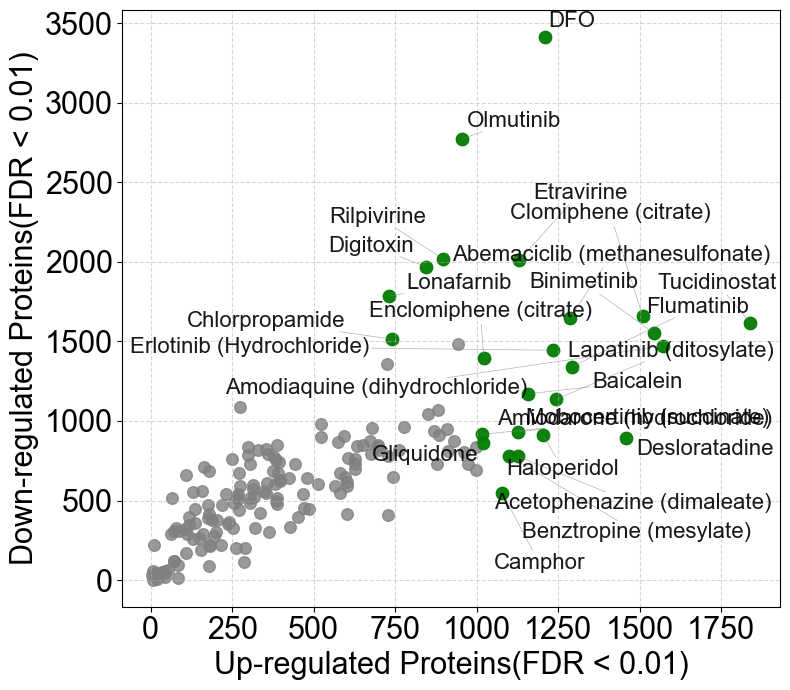

In [164]:
from adjustText import adjust_text

# summary has columns: drug, up, down, total
# Define threshold for strong dysregulation
up_thr = 1000
down_thr = 1500

strong = (summary["up"] >= up_thr) | (summary["down"] >= down_thr)

plt.figure(figsize=(8, 7))
plt.rcParams["font.family"] = "Arial" 
# Plot all drugs
plt.scatter(
    summary["up"],
    summary["down"],
    alpha=0.8,
    s=70,
    color="gray" 
    # label="All drugs"
)

# Highlight strong drugs
plt.scatter(
    summary.loc[strong, "up"],
    summary.loc[strong, "down"],
    alpha=0.9,
    s=80,
    color="green" 
    # label=f"Up ≥ {up_thr} & Down ≥ {down_thr}"
)

# Collect text objects
texts = []
for _, row in summary[strong].iterrows():
    texts.append(
        plt.text(
            row["up"],
            row["down"],
            row["drug"],
            fontsize=16,
            alpha=0.9
        )
    )

# Automatically adjust labels to avoid overlapping
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6)
)


plt.xlabel("Up-regulated Proteins(FDR < 0.01)",fontsize = 22)
plt.ylabel("Down-regulated Proteins(FDR < 0.01)",fontsize = 22)
plt.xticks(fontsize = 22)
plt.yticks(fontsize = 22)
# plt.title("Drug-Induced Dysregulation Pattern (Each drug = one dot)",fontsize = 16)
plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend()
plt.tight_layout()
plt.savefig(f'{figure_path}\scatter of drugs activity.svg', dpi=800)
plt.show()

# Scatter plot of proteome response

In [165]:
sig

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj
2,CAST,6-Mercaptopurine,5.867678,3.658536e-06,24.343017,24.172447,0.170570,1.058762e-04
5,COL18A1,6-Mercaptopurine,-15.412813,7.015235e-07,21.614175,22.308594,-0.694419,2.933373e-05
6,RBM47,6-Mercaptopurine,16.378758,8.468865e-12,15.353409,14.171787,1.181622,2.160246e-09
24,FAM234B,6-Mercaptopurine,4.802588,2.160197e-04,16.266348,15.658312,0.608037,2.334038e-03
28,SBNO1,6-Mercaptopurine,-4.905160,2.902245e-04,22.967888,23.129817,-0.161929,2.917311e-03
...,...,...,...,...,...,...,...,...
1339933,WASF2,DFO,9.218116,1.758306e-11,26.047940,25.637287,0.410653,4.078990e-09
1339935,FAM169A,DFO,11.023201,4.668484e-14,24.578848,24.079225,0.499623,2.322008e-11
1339936,ZHX2,DFO,13.283740,3.143377e-16,21.415553,20.744229,0.671323,2.922927e-13
1339938,IVNS1ABP,DFO,-26.985476,1.659475e-28,21.916716,23.581585,-1.664869,6.539992e-24


In [180]:
# Compute per-protein up/down counts across all drugs
protein_summary = sig.groupby("protein").apply(
    lambda g: pd.Series({
        "up": (g["log2FC"] > 0).sum(),
        "down": (g["log2FC"] < 0).sum(),
        "total": len(g)
    })
).reset_index()

print(protein_summary.head())
print(protein_summary.shape)

  protein  up  down  total
0    A1CF  20    21     41
1     A2M  31    22     53
2    AAAS   2    18     20
3    AACS  16     5     21
4   AADAT   0     2      2
(7761, 4)


C:\Users\jiangy5\AppData\Local\Temp\ipykernel_18728\843801779.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  protein_summary = sig.groupby("protein").apply(


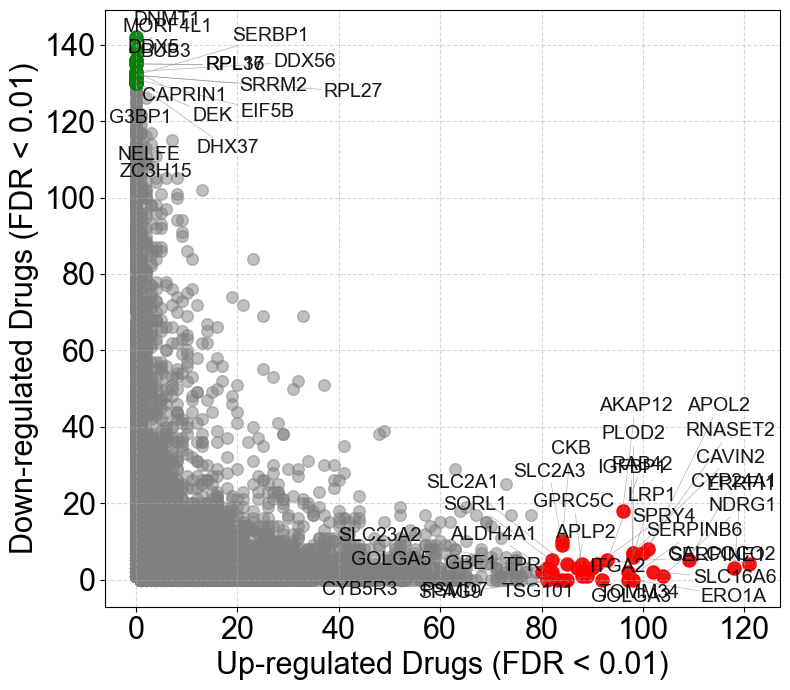

In [181]:
up_thr_pro = 80
down_thr_pro = 130

# Define masks
mask_up = protein_summary["up"] >= up_thr_pro
mask_down = protein_summary["down"] >= down_thr_pro
mask_sig = mask_up | mask_down  # any significant point

plt.figure(figsize=(8, 7))

# 1. Plot all background drugs (gray)
plt.scatter(
    protein_summary["up"],
    protein_summary["down"],
    alpha=0.5,
    s=70,
    color="gray"
)

# 2. Highlight significant UP points (red)
plt.scatter(
    protein_summary.loc[mask_up, "up"],
    protein_summary.loc[mask_up, "down"],
    alpha=0.9,
    s=90,
    color="red",
    label=f"Up >= {up_thr_pro}"
)

# 3. Highlight significant DOWN points (blue)
plt.scatter(
    protein_summary.loc[mask_down, "up"],
    protein_summary.loc[mask_down, "down"],
    alpha=0.9,
    s=90,
    color="green",
    label=f"Down >= {down_thr_pro}"
)

# Optional: label only significant points
texts = []
for _, row in protein_summary[mask_sig].iterrows():
    texts.append(
        plt.text(
            row["up"],
            row["down"],
            row["protein"],
            fontsize=14,
            alpha=0.9
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6)
)

# Axis labels & aesthetics
plt.xlabel("Up-regulated Drugs (FDR < 0.01)", fontsize=22)
plt.ylabel("Down-regulated Drugs (FDR < 0.01)", fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.grid(True, linestyle="--", alpha=0.5)
# plt.legend(fontsize=16)
plt.tight_layout()

plt.savefig(f"{figure_path}/scatter of proteome response rate.svg", dpi=800)
plt.show()


# DFO vs DMSO

In [170]:


df_dfo2 = df_dfo.dropna(subset=["log2FC"])

print("Number of proteins in DFO vs DMSO:", df_dfo2.shape[0])

Number of proteins in DFO vs DMSO: 7882


In [124]:
# Sort proteins by log2FC (e.g., from most down to most up)
df_dfo2 = df_dfo2.sort_values("log2FC").reset_index(drop=True)

# Create rank (1..N)
df_dfo2["rank"] = np.arange(1, len(df_dfo2) + 1)

# Number of highlighted proteins
top_n = 8

selected_proteins = [
    "P19367",  # HK1
    "P52789",  # HK2
    "P06744",  # GPI
    "P17858",  # PFKL
    "P08237",  # PFKM
    "Q01813",  # PFKP
    "P04075",  # ALDOA
    "P05062",  # ALDOB
    # "P09972",  # ALDOC
    "P60174",  # TPI1
    # "P04406",  # GAPDH
    "P00558",  # PGK1
    "P18669",  # PGAM1
    # "P06733",  # ENO1
    "P09104",  # ENO2
    "P21589",  # ENO3
    "P14618",  # PKM
    # "P30613",  # PKLR
    "P00338",  # LDHA
    "P07195",   # LDHB
      # Complex I
    "P28331",
    "P19404",
    # Complex II
    "P31040",
    # Complex IV
    "P13073",
    # Heme biosynthesis
    "P13196","P22830"]

#     "Q9NYK5",
#     "P14854",
#     "P08574",
#     "P12074",
#     "P13183",
#     "Q5U5X0",
#     "Q9BW72"
# ]

# Take the most down-regulated proteins
df_highlight = df_dfo2[df_dfo2["protein"].isin(selected_proteins)].copy()  # selected proteins to label

print(df_highlight[["protein", "log2FC"]])

print("Found selected proteins in DFO dataset:")

     protein    log2FC
17    P28331 -1.548645
44    P13196 -1.386652
74    P19404 -1.274667
119   P22830 -1.169889
282   P31040 -0.941372
551   P13073 -0.773283
5640  P06744  0.028770
6010  P18669  0.080306
6142  P60174  0.101329
6329  P17858  0.132951
7023  Q01813  0.303646
7373  P00338  0.447599
7429  P14618  0.486585
7444  P04075  0.496094
7624  P00558  0.669447
7753  P09104  0.909613
7822  P52789  1.180792
7908  P19367  2.157315
Found selected proteins in DFO dataset:


In [125]:
corresponding_genes = ["HK1","HK2","GPI","PFKL","PFKM","PFKP","ALDOA",
"ALDOB", # "ALDOC",
"TPI1",# "GAPDH",
"PGK1","PGAM1",# "ENO1",
"ENO2","ENO3","PKM",# "PKLR",
"LDHA","LDHB",
    # Complex I
    "NDUFS1",
    "NDUFV1",
    # Complex II
    "SDHA",
    # Complex IV
    "COX4I1",
    # Heme biosynthesis
    "ALAS1","FECH"]


# mito_respiratory_genes = [
#     "NDUFV2",   # Q9NYK5
#     "UQCRC2",   # P14854
#     "CYC1",     # P08574
#     "COX6A1",   # P12074
#     "COX7B",    # P13183
#     "LYRM7",    # Q5U5X0
#     "HIGD2A"    # Q9BW72
# ]

In [126]:
# ---- 1. Uniprot → Gene name map ----
uniprot_to_gene = dict(zip(selected_proteins, corresponding_genes))



In [127]:
df_highlight

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,rank
17,P28331,DFO,-34.265550,1.432168e-25,23.403288,24.951933,-1.548645,18
44,P13196,DFO,-10.101738,1.712854e-10,18.269421,19.656072,-1.386652,45
74,P19404,DFO,-23.230476,1.972727e-20,23.268806,24.543473,-1.274667,75
119,P22830,DFO,-22.712700,1.485794e-21,21.221272,22.391161,-1.169889,120
282,P31040,DFO,-8.999935,5.196478e-10,25.307181,26.248553,-0.941372,283
551,P13073,DFO,-7.879849,8.693264e-09,27.018053,27.791336,-0.773283,552
5640,P06744,DFO,0.271890,7.875969e-01,27.598331,27.569561,0.028770,5641
6010,P18669,DFO,0.726047,4.735148e-01,29.313433,29.233127,0.080306,6011
6142,P60174,DFO,0.950230,3.496232e-01,28.229662,28.128333,0.101329,6143
6329,P17858,DFO,3.321921,2.589572e-03,25.947007,25.814057,0.132951,6330


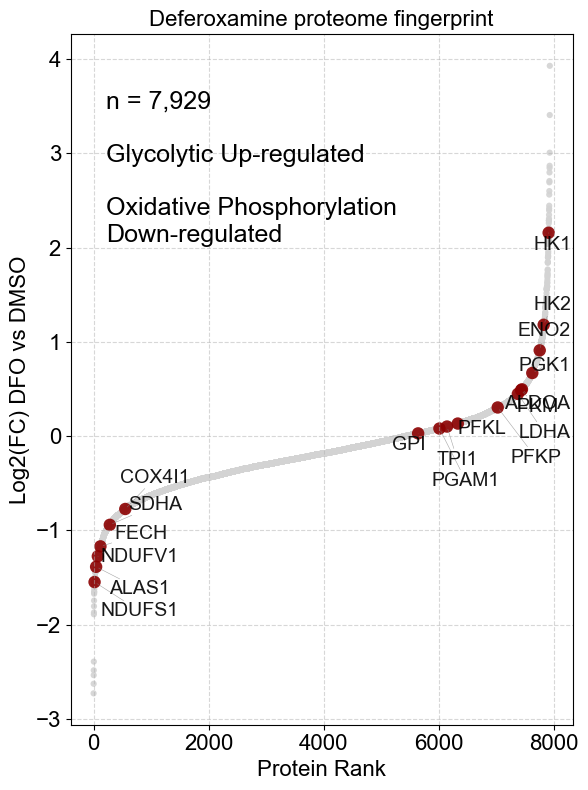

In [135]:
plt.figure(figsize=(6, 8))

# 1) All proteins as gray dots
plt.scatter(
    df_dfo2["rank"],
    df_dfo2["log2FC"],
    s=20,
    color="lightgray",
    edgecolors="none",
    alpha=0.9,
)

# 2) Highlight selected proteins in red
plt.scatter(
    df_highlight["rank"],
    df_highlight["log2FC"],
    s=80,
    color="darkred",
    edgecolors="none",
    alpha=0.9,
)

# # 3) Add labels for highlighted proteins
# for _, row in df_highlight.iterrows():
#     plt.text(
#         row["rank"],
#         row["log2FC"],
#         row["protein"],
#         fontsize=10,
#         ha="left",
#         va="center",
#         alpha=0.9
#     )

# ---- 4. Prepare label objects for adjustText
texts = []
for _, row in df_highlight.iterrows():
    uniprot_id = row["protein"]
    gene_name = uniprot_to_gene.get(uniprot_id, uniprot_id)

    texts.append(
        plt.text(
            row["rank"],
            row["log2FC"],
            gene_name,
            fontsize=14,
            ha="left",
            va="center",
            alpha=0.9
        )
    )

# ---- 5. Prevent label overlap ----
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", lw=0.4, color="gray", alpha=0.7)
)

# Axis labels and title
plt.xlabel("Protein Rank",fontsize = 16)
plt.ylabel("Log2(FC) DFO vs DMSO",fontsize = 16)
plt.xticks([0,2000,4000,6000,8000],fontsize = 16)
plt.yticks(fontsize = 16)
plt.title("Deferoxamine proteome fingerprint",fontsize = 16)

# Optional: show total number of proteins on the plot
n_prot = df_dfo2.shape[0]

plt.text(
    0.07, 0.70,
    f"n = {n_prot:,}\n\nGlycolytic Up-regulated \n\nOxidative Phosphorylation \nDown-regulated",
    transform=plt.gca().transAxes,
    fontsize=18
)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f'{figure_path}\Fingerprint of DFO vs DMSO.svg', dpi=800)
plt.show()


# volcano plot of select drug 

In [171]:

# =========================
# 1. Load your data
# =========================
df_stats = df_ttest_alldrugs2.copy()  # contains drug, protein, p_value, log2FC?
df_expr  = df.copy()     # contains expression values (if needed)

# Inspect column names
print(df_stats.columns)


Index(['protein', 'drug', 't_stat', 'p_value', 'mean_drug', 'mean_DMSO',
       'log2FC', 'p_value_adj'],
      dtype='object')


In [172]:
def plot_volcano(
        df,
        drug_name,
        fc_col="log2FC",
        p_col="p_value_adj",   # adjusted p-value
        protein_col="protein",
        fc_thresh=1.0,
        p_thresh=0.05,
        figsize=(6,5)
    ):
    
    # Filter selected drug
    d = df[df["drug"] == drug_name].copy()
    
    # Compute negative log10 (avoid -inf)
    d["neglog10p"] = -np.log10(d[p_col].replace(0, np.nan))

    # Significance mask
    d["sig_up"] = (d[p_col] < p_thresh) & (d[fc_col] >  fc_thresh)
    d["sig_down"] = (d[p_col] < p_thresh) & (d[fc_col] < -fc_thresh)

    # Base plot: all non-significant points (gray)
    plt.figure(figsize=figsize)
    nonsig = d[~(d["sig_up"] | d["sig_down"])]
    plt.scatter(nonsig[fc_col], nonsig["neglog10p"], color="gray", alpha=0.5)

    # Upregulated proteins (red)
    up = d[d["sig_up"]]
    plt.scatter(up[fc_col], up["neglog10p"], color="red", alpha=0.9, label="Upregulated")

    # Downregulated proteins (green)
    down = d[d["sig_down"]]
    plt.scatter(down[fc_col], down["neglog10p"], color="green", alpha=0.9, label="Downregulated")

    # Text labels (non overlapping)
    texts = []
    for _, row in pd.concat([up, down]).iterrows():
        texts.append(
            plt.text(row[fc_col], row["neglog10p"], row[protein_col], fontsize=12)
        )
    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.5))

    # Threshold lines
    plt.axvline(fc_thresh, color="black", ls="--")
    plt.axvline(-fc_thresh, color="black", ls="--")
    plt.axhline(-np.log10(p_thresh), color="black", ls="--")

    plt.xlabel("log2 Fold Change", fontsize=20)
    plt.ylabel("-log10 FDR (adjusted p-value)", fontsize=20)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.title(f"Volcano Plot – {drug_name}")

    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'{figure_path}\\Volcano Plot – {drug_name}', dpi=800)
    plt.show()


In [173]:
df_stats

,protein,drug,t_stat,p_value,mean_drug,mean_DMSO,log2FC,p_value_adj
0,SMIM26,6-Mercaptopurine,-2.241855,6.262588e-02,19.459334,19.665528,-0.206194,1.614439e-01
1,MSANTD7,6-Mercaptopurine,-0.023353,9.821299e-01,14.012529,14.018722,-0.006192,9.904761e-01
2,CAST,6-Mercaptopurine,5.867678,3.658536e-06,24.343017,24.172447,0.170570,1.058762e-04
3,GNG5B,6-Mercaptopurine,-1.102815,3.111119e-01,16.492365,16.918388,-0.426023,4.887303e-01
4,NKRF,6-Mercaptopurine,-1.101862,2.855027e-01,22.137554,22.179205,-0.041650,4.618825e-01
...,...,...,...,...,...,...,...,...
1339935,FAM169A,DFO,11.023201,4.668484e-14,24.578848,24.079225,0.499623,2.322008e-11
1339936,ZHX2,DFO,13.283740,3.143377e-16,21.415553,20.744229,0.671323,2.922927e-13
1339937,MORC2,DFO,-0.509831,6.126959e-01,22.102131,22.128845,-0.026714,7.536040e-01
1339938,IVNS1ABP,DFO,-26.985476,1.659475e-28,21.916716,23.581585,-1.664869,6.539992e-24


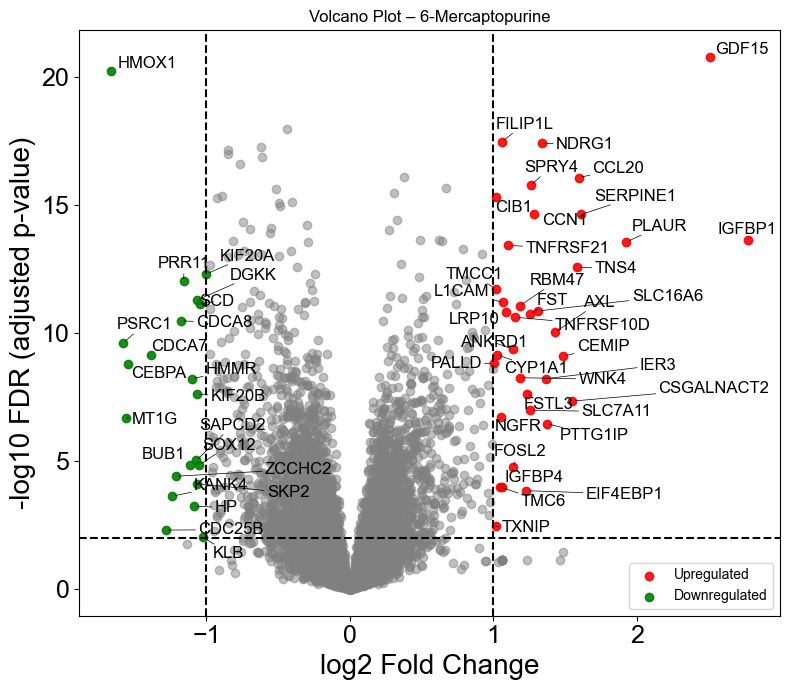

In [174]:
# =========================
# 3. Run for any drug
# =========================
plot_volcano(df_stats, drug_name="6-Mercaptopurine",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="protein",
             fc_thresh=1.0,
             p_thresh=0.01,
             figsize=(8,7)
            )

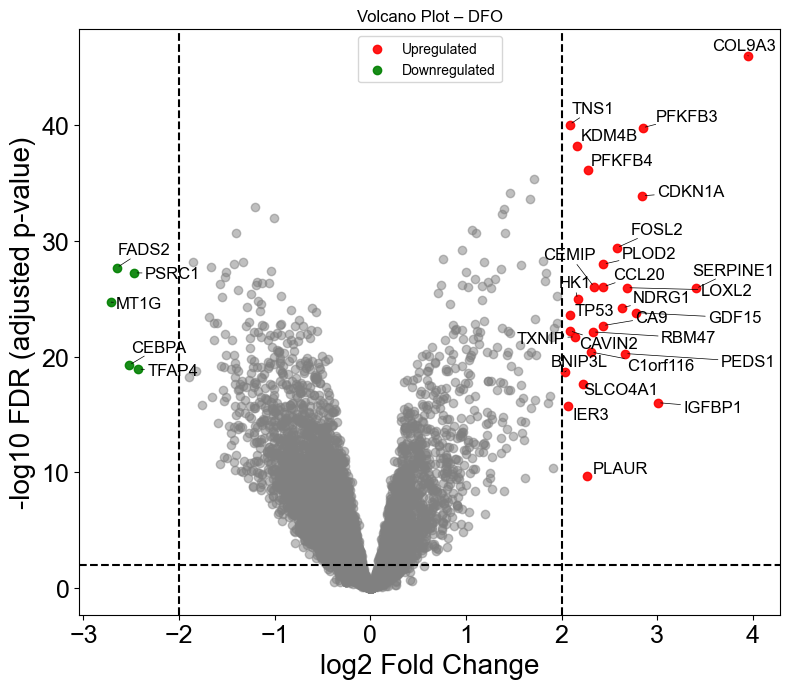

In [175]:
plot_volcano(df_stats, drug_name="DFO",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="protein",
             fc_thresh=2.0,
             p_thresh=0.01,
             figsize=(8,7)
            )

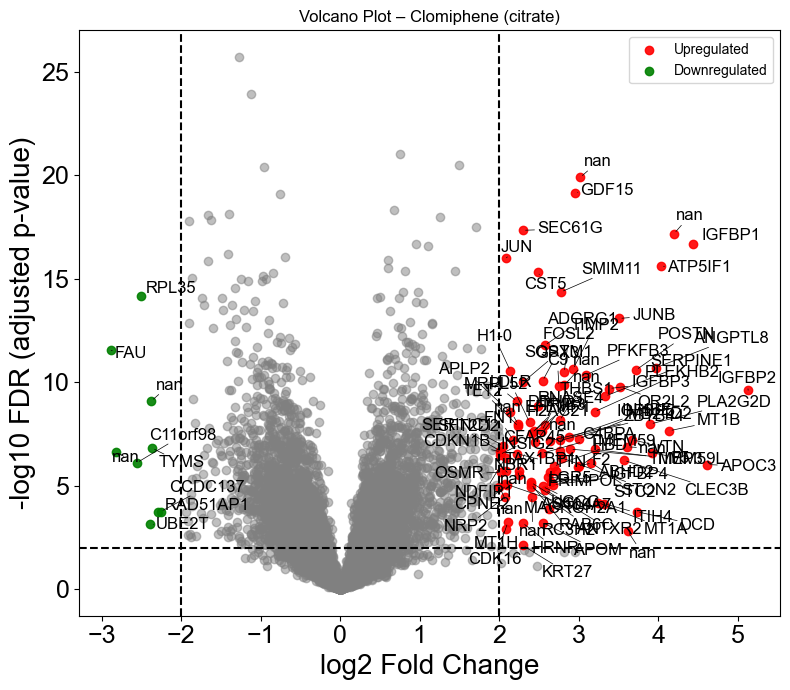

In [89]:
plot_volcano(df_stats, drug_name="Clomiphene (citrate)",
             fc_col="log2FC",
             p_col="p_value",
             protein_col="genename",
             fc_thresh=2.0,
             p_thresh=0.01,
             figsize=(8,7)
            )

# KEGG gene enrichment

In [92]:
import os
from typing import List, Dict, Optional
import gseapy as gp



In [116]:
# gene enrichment function

def run_enrichment_for_drug(
    df: pd.DataFrame,
    drug_name: str,
    log2fc_up: float = 1.0,
    log2fc_down: float = -1.0,
    fdr_cutoff: float = 0.05,
    species: str = "Human",
    top_n: int = 20,
    output_dir: str = "enrichment_by_drug",   # 🔥 用户可自定义
    direction: str = "both"                   # "up", "down", "both"
) -> Dict[str, Optional[Dict[str, pd.DataFrame]]]:
    """
    对指定 drug 的上调/下调基因做 KEGG/GO/Reactome 富集。
    
    df 必须包含:
      ['protein', 'drug', 't_stat', 'p_value', 'mean_drug', 
       'mean_DMSO', 'log2FC', 'p_value_adj', 'genename']
    """

    # 1) 只选指定 drug
    d = df[df["drug"] == drug_name].copy()
    if d.empty:
        print(f"❗ No rows found for drug = {drug_name}")
        return {"up": None, "down": None}

    # ==== 用户自定义输出路径 ====
    os.makedirs(output_dir, exist_ok=True)

    # 最终目录结构：
    #   output_dir / DrugName / UP / ...
    #   output_dir / DrugName / DOWN / ...
    drug_dir = os.path.join(output_dir, drug_name.replace("/", "_"))
    os.makedirs(drug_dir, exist_ok=True)

    # 2) gene sets
    gene_sets = {
        "KEGG": "KEGG_2021_Human",
        "GO_BP": "GO_Biological_Process_2021",
        "GO_MF": "GO_Molecular_Function_2021",
        "GO_CC": "GO_Cellular_Component_2021",
        "Reactome": "Reactome_2022",
    }

    # 3) 取上下调
    up_genes = d.loc[
        (d["log2FC"] >= log2fc_up) & (d["p_value_adj"] <= fdr_cutoff),
        "genename"
    ].dropna().unique().tolist()

    down_genes = d.loc[
        (d["log2FC"] <= log2fc_down) & (d["p_value_adj"] <= fdr_cutoff),
        "genename"
    ].dropna().unique().tolist()

    print(f"[{drug_name}] Up-regulated genes:   {len(up_genes)}")
    print(f"[{drug_name}] Down-regulated genes: {len(down_genes)}")

    results = {"up": None, "down": None}

    # ==== helper function ====
    def enrich_one(gene_list, label, outdir):
        if len(gene_list) == 0:
            print(f"[{drug_name} - {label}] No genes to enrich.")
            return None

        os.makedirs(outdir, exist_ok=True)
        result_dict: Dict[str, pd.DataFrame] = {}

        for tag, gs in gene_sets.items():
            print(f"[{drug_name} - {label}] Running {tag} enrichment...")

            enr = gp.enrichr(
                gene_list=gene_list,
                gene_sets=gs,
                organism=species,
                cutoff=fdr_cutoff,
                outdir=None
            )

            res = enr.res2d
            if res is None or res.empty:
                print(f"[{drug_name} - {label}] {tag}: no significant terms.")
                continue

            # sort by adjusted p-value
            if "Adjusted P-value" in res.columns:
                res_sorted = res.sort_values("Adjusted P-value")
            else:
                res_sorted = res.sort_values(res.columns[2])

            top_res = res_sorted.head(top_n)

            # save CSV
            save_path = os.path.join(outdir, f"{tag}_top{top_n}.csv")
            top_res.to_csv(save_path, index=False)
            print(f"[{drug_name} - {label}] Saved: {save_path}")

            result_dict[tag] = top_res

        return result_dict

    # ==== RUN enrichment for UP / DOWN ====
    if direction in ("up", "both"):
        up_dir = os.path.join(drug_dir, "UP")
        results["up"] = enrich_one(up_genes, "UP", up_dir)

    if direction in ("down", "both"):
        down_dir = os.path.join(drug_dir, "DOWN")
        results["down"] = enrich_one(down_genes, "DOWN", down_dir)

    print(f"[{drug_name}] Enrichment completed.")
    return results


In [95]:
res = run_enrichment_for_drug(
    df=df_ttest_alldrugs2,
    drug_name="DFO",
    log2fc_up=0.5,
    log2fc_down=-0.5,
    fdr_cutoff=0.05,
    top_n=20,
    output_dir= file_path,
    direction="both"
)

[DFO] Up-regulated genes:   478
[DFO] Down-regulated genes: 1599
[DFO - UP] Running KEGG enrichment...
[DFO - UP] Saved: C:\project8  Robotics and AI enable automation in modern proteomics\files\DFO\UP\KEGG_top20.csv
[DFO - UP] Running GO_BP enrichment...
[DFO - UP] Saved: C:\project8  Robotics and AI enable automation in modern proteomics\files\DFO\UP\GO_BP_top20.csv
[DFO - UP] Running GO_MF enrichment...
[DFO - UP] Saved: C:\project8  Robotics and AI enable automation in modern proteomics\files\DFO\UP\GO_MF_top20.csv
[DFO - UP] Running GO_CC enrichment...
[DFO - UP] Saved: C:\project8  Robotics and AI enable automation in modern proteomics\files\DFO\UP\GO_CC_top20.csv
[DFO - UP] Running Reactome enrichment...
[DFO - UP] Saved: C:\project8  Robotics and AI enable automation in modern proteomics\files\DFO\UP\Reactome_top20.csv
[DFO - DOWN] Running KEGG enrichment...
[DFO - DOWN] Saved: C:\project8  Robotics and AI enable automation in modern proteomics\files\DFO\DOWN\KEGG_top20.csv
[DF

In [119]:
# plot enrichment results funciton

import matplotlib.pyplot as plt


def plot_enrichment_bubble_up_down(
    up_csv: str,
    down_csv: str,
    top_n: int = 10,
    title: Optional[str] = None,
    save_path: Optional[str] = None,
):
    """
    从上调和下调 enrichment CSV 画 bubble plot，
    上下调在一张图，颜色表示方向，bubble 大小表示基因数，
    并使用两个不重叠的 legend（方向 + 基因数）。
    """

    # ---------- 读取 CSV ----------
    df_up = pd.read_csv(up_csv)
    df_down = pd.read_csv(down_csv)

    # ---------- 按 Adjusted P-value 排序并取 top_n ----------
    df_up = df_up.sort_values("Adjusted P-value").head(top_n).copy()
    df_down = df_down.sort_values("Adjusted P-value").head(top_n).copy()

    # ---------- 基因数 ----------
    def get_gene_count(df):
        if "Overlap" in df.columns:
            # Overlap 形如 "5/200"
            return df["Overlap"].astype(str).str.split("/").str[0].astype(int)
        else:
            # 或者用 Genes 列，形如 "GENE1;GENE2;GENE3"
            return df["Genes"].astype(str).apply(
                lambda x: len([g for g in x.replace(",", ";").split(";") if g.strip()])
            )

    df_up["gene_count"] = get_gene_count(df_up)
    df_down["gene_count"] = get_gene_count(df_down)

    # ---------- 添加上下调标签 ----------
    df_up["direction"] = "Up"
    df_down["direction"] = "Down"

    df_all = pd.concat([df_up, df_down], ignore_index=True)

    df_all["neg_log10_FDR"] = -np.log10(df_all["Adjusted P-value"].replace(0, np.nan))

    # ---------- Pathway 排序 ----------
    term_order = (
        df_all.groupby("Term")["Adjusted P-value"]
        .min()
        .sort_values()
        .index
        .tolist()
    )
    df_all["Term"] = pd.Categorical(df_all["Term"], categories=term_order, ordered=True)

    # ---------- 画图 ----------
    fig_height = max(6, 0.4 * len(term_order) + 2)
    plt.figure(figsize=(10, fig_height))
    ax = plt.gca()

    color_map = {"Up": "red", "Down": "blue"}
    size_scale = 10

    # 分别保存 scatter 对象，用于颜色 legend
    scatter_handles = {}

    for direction in ["Up", "Down"]:
        sub = df_all[df_all["direction"] == direction]
        if sub.empty:
            continue

        sc = ax.scatter(
            sub["neg_log10_FDR"],
            sub["Term"],
            s=sub["gene_count"] * size_scale,
            c=color_map[direction],
            alpha=0.7,
            edgecolors="k",
            linewidths=0.5,
            label=direction,
        )
        scatter_handles[direction] = sc

    # ---------- 颜色 legend（方向 Up / Down） ----------
    direction_handles = []
    direction_labels = []
    for direction in ["Up", "Down"]:
        if direction in scatter_handles:
            direction_handles.append(scatter_handles[direction])
            direction_labels.append(direction)

    # 放在右上角
    leg1 = ax.legend(
        handles=direction_handles,
        labels=direction_labels,
        title="Direction",
        loc="upper right",
        fontsize=16,
        title_fontsize=16,
        borderpad=1.2,       # legend 内边距
        labelspacing=1.2,    # label 间距
        handletextpad=1.4,   # 点和文字之间距离
        borderaxespad=1.0,   # legend 与轴的间距
    )
    ax.add_artist(leg1)  # 把第一个 legend 固定在图上

    # ---------- Bubble size legend（基因数） ----------
    all_sizes = df_all["gene_count"]
    if len(all_sizes) >= 3:
        size_levels = np.percentile(all_sizes, [25, 50, 75]).astype(int)
    else:
        size_levels = sorted(all_sizes.unique())
        # 防止太少
        if len(size_levels) == 1:
            size_levels = [size_levels[0], size_levels[0] + 1, size_levels[0] + 2]

    size_handles = []
    size_labels = []
    for s in size_levels:
        h = ax.scatter(
            [],
            [],
            s=s * size_scale,
            c="gray",
            alpha=0.6,
            edgecolors="k",
            linewidths=0.5,
        )
        size_handles.append(h)
        size_labels.append(f"{s} genes")

    # 放在右下角
    leg2 = ax.legend(
        handles=size_handles,
        labels=size_labels,
        title="Gene count",
        loc="lower right",
        fontsize=16,
        title_fontsize=16,
        borderpad=1.2,       # legend 内边距
        labelspacing=1.2,    # label 间距
        handletextpad=1.4,   # 点和文字之间距离
        borderaxespad=1.0,   # legend 与轴的间距
    )

    # ---------- 轴 & 外观 ----------
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=14)
    ax.set_ylabel("Pathway / Term", fontsize=14)
    if title:
        ax.set_title(title, fontsize=16)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()

    # ---------- 保存 ----------
    if save_path is not None:
        outdir = os.path.dirname(save_path)
        if outdir != "":
            os.makedirs(outdir, exist_ok=True)
        plt.savefig(save_path, dpi=300)
        print(f"Bubble plot saved to {save_path}")

    plt.show()


Bubble plot saved to C:/project8  Robotics and AI enable automation in modern proteomics/figures/DFO_GOCC_bubble_up_down.svg


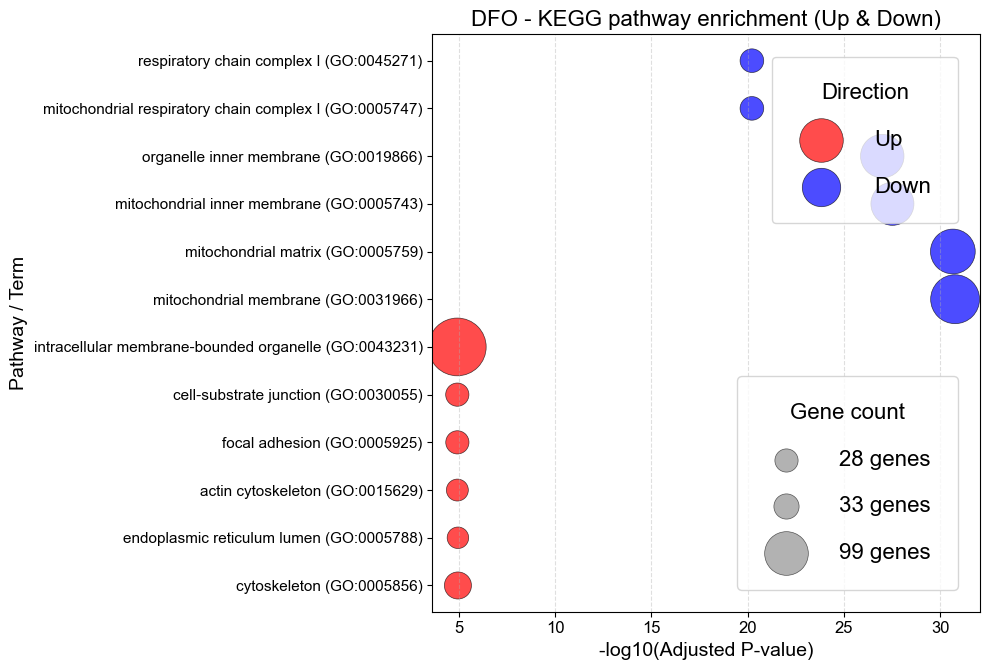

In [120]:
up_csv = r"C:/project8  Robotics and AI enable automation in modern proteomics/files/DFO/UP/GO_CC_top20.csv"
down_csv = r"C:/project8  Robotics and AI enable automation in modern proteomics/files/DFO/DOWN/GO_CC_top20.csv"

plot_enrichment_bubble_up_down(
    up_csv=up_csv,
    down_csv=down_csv,
    top_n=6,  # 从 up/down 各取 10 个通路
    title="DFO - KEGG pathway enrichment (Up & Down)",
    save_path=r"C:/project8  Robotics and AI enable automation in modern proteomics/figures/DFO_GOCC_bubble_up_down.svg"
)

In [ ]:
# 对每一个drug 进行 蛋白的分析 和代谢通路的分析

In [ ]:
# 当你有一个巨大的数据集的时候，使用LLM 来一个个的分析是否是一个好的方式呢? 

